In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp, pointbiserialr
from sklearn.metrics import mutual_info_score

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
RANDOM_STATE = 42

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data" / "processed" / "feature_manifest.json").exists():
            return candidate
    raise FileNotFoundError("Project root was not found")

PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
X_train = pd.read_parquet(PROCESSED_DIR / "X_train_expert.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "X_test_expert.parquet")
y_train_frame = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")
train_ids = pd.read_parquet(PROCESSED_DIR / "train_ids.parquet")
test_ids = pd.read_parquet(PROCESSED_DIR / "test_ids.parquet")
manifest = json.loads((PROCESSED_DIR / "feature_manifest.json").read_text(encoding="utf-8"))
metadata = json.loads((PROCESSED_DIR / "preprocessing_metadata.json").read_text(encoding="utf-8"))
y_train = y_train_frame[metadata["target_name"]]

artifact_summary = pd.Series({
    "X_train_shape": str(X_train.shape),
    "X_test_shape": str(X_test.shape),
    "y_train_shape": str(y_train_frame.shape),
    "train_ids_shape": str(train_ids.shape),
    "test_ids_shape": str(test_ids.shape),
    "total_features": X_train.shape[1],
    "train_memory_MiB": X_train.memory_usage(deep=True).sum() / 2**20,
    "test_memory_MiB": X_test.memory_usage(deep=True).sum() / 2**20,
})
display(artifact_summary.to_frame("value"))

,value
X_train_shape,"(114321, 313)"
X_test_shape,"(114393, 313)"
y_train_shape,"(114321, 1)"
train_ids_shape,"(114321, 1)"
test_ids_shape,"(114393, 1)"
total_features,313
train_memory_MiB,170.515228
test_memory_MiB,170.622620


,feature_group,feature_count,percentage_of_total
0,original_numerical,12,3.833866
1,numerical_pair_sums,66,21.086262
2,categorical_1way,13,4.153355
3,categorical_2way,78,24.920128
4,categorical_3way_v22,66,21.086262
5,high_order_v22_interactions,66,21.086262
6,rounded_numeric_categories,12,3.833866


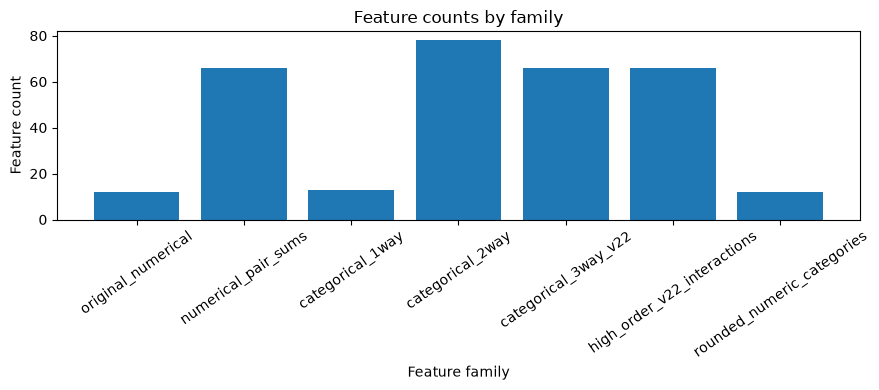

In [4]:
required_manifest_keys = {"final_feature_names", "categorical_feature_names", "categorical_feature_indices", "feature_origin", "generated_feature_counts", "total_features"}

categorical_features = manifest["categorical_feature_names"]
categorical_indices = manifest["categorical_feature_indices"]
categorical_set = set(categorical_features)
numerical_features = [feature for feature in X_train.columns if feature not in categorical_set]
feature_info = pd.DataFrame({"feature": X_train.columns})
feature_info["feature_group"] = feature_info["feature"].map(manifest["feature_origin"])
feature_info["semantic_type"] = np.where(feature_info["feature"].isin(categorical_set), "categorical", "numerical")

feature_group_summary = (feature_info.groupby("feature_group", sort=False).size().rename("feature_count").reset_index())
feature_group_summary["percentage_of_total"] = 100 * feature_group_summary["feature_count"] / len(feature_info)

feature_group_summary.to_csv(METRICS_DIR / "feature_group_summary.csv", index=False)
display(feature_group_summary)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(feature_group_summary["feature_group"], feature_group_summary["feature_count"])
ax.set(title="Feature counts by family", xlabel="Feature family", ylabel="Feature count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_analysis_feature_groups.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
feature_semantics_summary = (feature_info.groupby("semantic_type").size().rename("feature_count").reset_index())
feature_semantics_summary.to_csv(METRICS_DIR / "feature_semantics_summary.csv", index=False)
display(feature_semantics_summary)

,semantic_type,feature_count
0,categorical,235
1,numerical,78


,feature,train_missing_count,train_missing_rate,test_missing_count,test_missing_rate,feature_group,semantic_type,missing_rate_difference
48,num2sum__v21__v114,637,0.005572,596,0.005210,numerical_pair_sums,numerical,-0.000362
42,num2sum__v21__v34,635,0.005555,594,0.005193,numerical_pair_sums,numerical,-0.000362
44,num2sum__v21__v40,635,0.005555,594,0.005193,numerical_pair_sums,numerical,-0.000362
45,num2sum__v21__v50,613,0.005362,575,0.005027,numerical_pair_sums,numerical,-0.000336
24,num2sum__v12__v21,613,0.005362,575,0.005027,numerical_pair_sums,numerical,-0.000336
47,num2sum__v21__v72,611,0.005345,573,0.005009,numerical_pair_sums,numerical,-0.000336
3,v21,611,0.005345,573,0.005009,original_numerical,numerical,-0.000336
33,num2sum__v14__v21,611,0.005345,573,0.005009,numerical_pair_sums,numerical,-0.000336
46,num2sum__v21__v62,611,0.005345,573,0.005009,numerical_pair_sums,numerical,-0.000336
14,num2sum__v10__v21,611,0.005345,573,0.005009,numerical_pair_sums,numerical,-0.000336


,feature_group,feature_count,features_with_missing,total_missing_train,total_missing_test,mean_missing_rate_train,mean_missing_rate_test
0,numerical_pair_sums,66,60,10966,10310,0.001453,0.001366
1,original_numerical,12,8,1123,1057,0.000819,0.000770
2,high_order_v22_interactions,66,0,0,0,0.000000,0.000000
3,rounded_numeric_categories,12,0,0,0,0.000000,0.000000
4,categorical_1way,13,0,0,0,0.000000,0.000000
5,categorical_2way,78,0,0,0,0.000000,0.000000
6,categorical_3way_v22,66,0,0,0,0.000000,0.000000


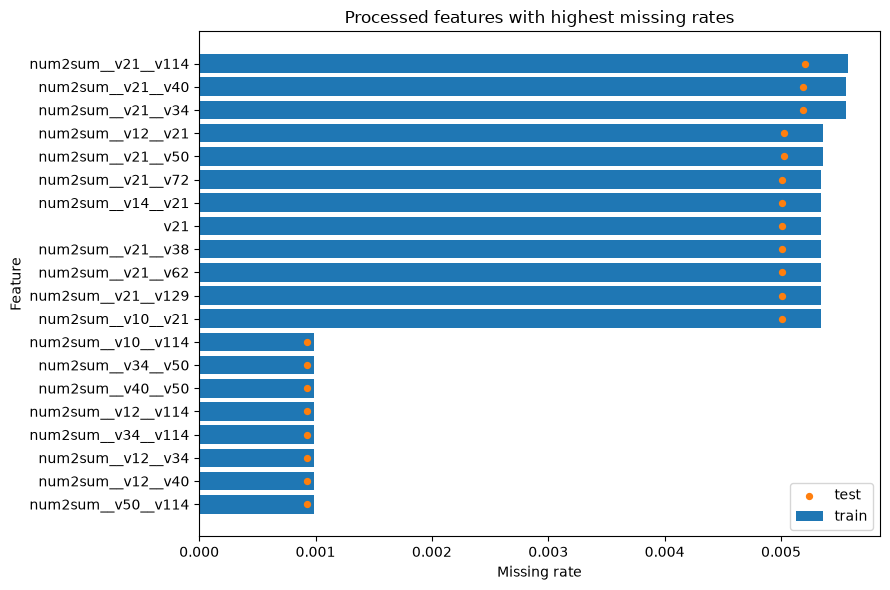

In [7]:
train_missing_count = X_train.isna().sum()
test_missing_count = X_test.isna().sum()

feature_missingness = pd.DataFrame({
    "feature": X_train.columns,
    "train_missing_count": train_missing_count.to_numpy(),
    "train_missing_rate": (train_missing_count / len(X_train)).to_numpy(),
    "test_missing_count": test_missing_count.to_numpy(),
    "test_missing_rate": (test_missing_count / len(X_test)).to_numpy(),
}).merge(feature_info, on="feature")
feature_missingness["missing_rate_difference"] = feature_missingness["test_missing_rate"] - feature_missingness["train_missing_rate"]
feature_missingness = feature_missingness.sort_values("train_missing_rate", ascending=False)
feature_missingness.to_csv(METRICS_DIR / "feature_missingness.csv", index=False)

missingness_by_group = feature_missingness.groupby("feature_group", sort=False).agg(
    feature_count=("feature", "size"),
    features_with_missing=("train_missing_count", lambda values: int((values > 0).sum())),
    total_missing_train=("train_missing_count", "sum"),
    total_missing_test=("test_missing_count", "sum"),
    mean_missing_rate_train=("train_missing_rate", "mean"),
    mean_missing_rate_test=("test_missing_rate", "mean"),
).reset_index()
display(feature_missingness.loc[feature_missingness["train_missing_count"] > 0].head(20))
display(missingness_by_group)

missing_features = feature_missingness.loc[feature_missingness["train_missing_count"] > 0].head(20).sort_values("train_missing_rate")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(missing_features["feature"], missing_features["train_missing_rate"], label="train")
ax.scatter(missing_features["test_missing_rate"], missing_features["feature"], label="test", s=18)
ax.set(title="Processed features with highest missing rates", xlabel="Missing rate", ylabel="Feature")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_analysis_missingness.png", dpi=150, bbox_inches="tight")
plt.show()

,train_unique,test_unique,test_only_ratio
count,235.000000,235.000000,235.000000
mean,"51,414.327660","11,569.897872",0.002872
std,"44,660.745114","10,244.759247",0.008274
min,3.000000,3.000000,0.000000
25%,167.000000,135.500000,0.000038
50%,"50,710.000000","10,890.000000",0.000071
75%,"106,099.500000","22,682.000000",0.000096
90%,"108,180.000000","26,010.400000",0.008653
99%,"113,507.660000","29,078.000000",0.042296
max,"114,194.000000","29,235.000000",0.058824


,feature_group,feature_count,median_train_cardinality,max_train_cardinality,median_test_only_ratio
0,categorical_1way,13,10.000000,18211,0.000000
1,categorical_2way,78,114.000000,65670,0.002179
2,categorical_3way_v22,66,"54,210.000000",95876,0.000040
3,rounded_numeric_categories,12,"85,871.500000",114194,0.000153
4,high_order_v22_interactions,66,"107,831.500000",108403,0.000091


,feature,train_unique,test_unique,train_unique_ratio,test_unique_ratio,shared_values,train_only_values,test_only_values,test_only_ratio,feature_group,semantic_type,cardinality_group
161,rnum__v34,114194,33,0.998889,0.000288,32,114162,1,0.030303,rounded_numeric_categories,categorical,very_high
158,rnum__v12,114127,281,0.998303,0.002456,280,113847,1,0.003559,rounded_numeric_categories,categorical,very_high
160,rnum__v21,113576,235,0.993483,0.002054,234,113342,1,0.004255,rounded_numeric_categories,categorical,very_high
164,rnum__v50,113375,1662,0.991725,0.014529,1661,111714,1,0.000602,rounded_numeric_categories,categorical,very_high
163,rnum__v40,112862,2634,0.987238,0.023026,2633,110229,1,0.000380,rounded_numeric_categories,categorical,very_high
167,rnum__v114,111976,4229,0.979488,0.036969,4228,107748,1,0.000236,rounded_numeric_categories,categorical,very_high
213,cat11__v22__v24__v30__v52__v56__v66__v75__v79_...,108403,10299,0.948233,0.090032,10298,98105,1,0.000097,high_order_v22_interactions,categorical,very_high
198,cat11__v22__v24__v30__v31__v52__v56__v66__v75_...,108384,10332,0.948067,0.090320,10331,98053,1,0.000097,high_order_v22_interactions,categorical,very_high
206,cat11__v22__v24__v30__v47__v52__v56__v66__v75_...,108384,10332,0.948067,0.090320,10331,98053,1,0.000097,high_order_v22_interactions,categorical,very_high
173,cat11__v22__v24__v30__v31__v47__v52__v56__v66_...,108337,10406,0.947656,0.090967,10405,97932,1,0.000096,high_order_v22_interactions,categorical,very_high


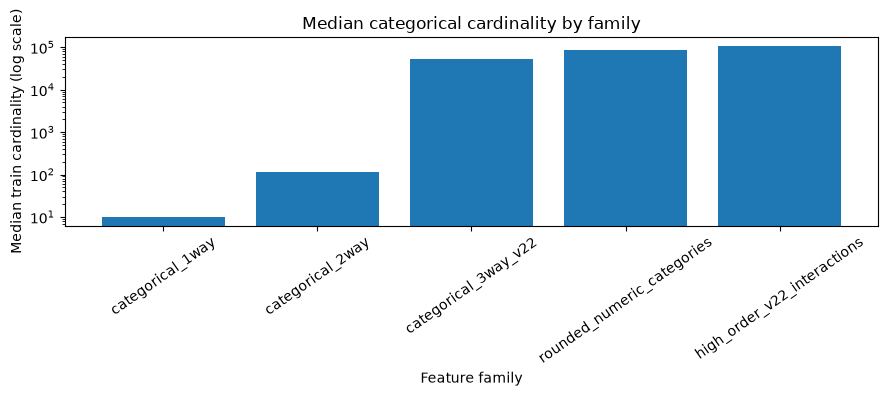

In [8]:
cardinality_rows = []

for feature in categorical_features:
    train_values = np.unique(X_train[feature].to_numpy())
    test_values = np.unique(X_test[feature].to_numpy())
    shared_count = np.intersect1d(train_values, test_values, assume_unique=True).size
    train_only_count = train_values.size - shared_count
    test_only_count = test_values.size - shared_count
    cardinality_rows.append({
        "feature": feature,
        "train_unique": train_values.size,
        "test_unique": test_values.size,
        "train_unique_ratio": train_values.size / len(X_train),
        "test_unique_ratio": test_values.size / len(X_test),
        "shared_values": shared_count,
        "train_only_values": train_only_count,
        "test_only_values": test_only_count,
        "test_only_ratio": test_only_count / max(test_values.size, 1),
    })

feature_cardinality = pd.DataFrame(cardinality_rows).merge(feature_info, on="feature")
feature_cardinality["cardinality_group"] = pd.cut(
    feature_cardinality["train_unique"],
    bins=[-np.inf, 20, 200, 20_000, 100_000, np.inf],
    labels=["very_low", "low", "medium", "high", "very_high"],
)
feature_cardinality.to_csv(METRICS_DIR / "feature_cardinality.csv", index=False)

cardinality_by_group = feature_cardinality.groupby("feature_group", sort=False, observed=True).agg(
    feature_count=("feature", "size"),
    median_train_cardinality=("train_unique", "median"),
    max_train_cardinality=("train_unique", "max"),
    median_test_only_ratio=("test_only_ratio", "median"),
).reset_index()

display(feature_cardinality[["train_unique", "test_unique", "test_only_ratio"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))
display(cardinality_by_group)
display(feature_cardinality.sort_values("train_unique", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cardinality_by_group["feature_group"], cardinality_by_group["median_train_cardinality"])
ax.set_yscale("log")
ax.set(title="Median categorical cardinality by family", xlabel="Feature family", ylabel="Median train cardinality (log scale)")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_analysis_cardinality.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
profile_rows = []
for feature in X_train.columns:
    counts = X_train[feature].value_counts(dropna=False)
    profile_rows.append({
        "feature": feature,
        "nunique": counts.size,
        "dominant_value_frequency": counts.iloc[0] / len(X_train),
    })

feature_concentration = pd.DataFrame(profile_rows).merge(feature_info, on="feature")
feature_concentration["constant"] = feature_concentration["nunique"] <= 1
feature_concentration["near_constant"] = feature_concentration["dominant_value_frequency"] >= 0.995

constant_features = feature_concentration.loc[feature_concentration["constant"]].copy()

near_constant_features = feature_concentration.loc[feature_concentration["near_constant"]].copy()
near_constant_features.to_csv(METRICS_DIR / "feature_near_constant.csv", index=False)

fingerprint_groups = {}
for feature in X_train.columns:
    hashes = pd.util.hash_pandas_object(X_train[feature], index=False).to_numpy(dtype=np.uint64)
    fingerprint = (str(X_train[feature].dtype), int(hashes.sum(dtype=np.uint64)), int(np.bitwise_xor.reduce(hashes)))
    fingerprint_groups.setdefault(fingerprint, []).append(feature)

duplicate_rows = []
for candidates in fingerprint_groups.values():
    for left_index, feature_a in enumerate(candidates):
        for feature_b in candidates[left_index + 1:]:
            if X_train[feature_a].equals(X_train[feature_b]):
                duplicate_rows.append({
                    "feature_a": feature_a,
                    "feature_b": feature_b,
                    "feature_group_a": manifest["feature_origin"][feature_a],
                    "feature_group_b": manifest["feature_origin"][feature_b],
                })

feature_duplicates = pd.DataFrame(duplicate_rows, columns=["feature_a", "feature_b", "feature_group_a", "feature_group_b"])
feature_duplicates.to_csv(METRICS_DIR / "feature_duplicates.csv", index=False)

print(f"Constant features: {len(constant_features)}")
print(f"Near-constant features: {len(near_constant_features)}")
print(f"Exact duplicate pairs: {len(feature_duplicates)}")

Constant features: 0
Near-constant features: 0
Exact duplicate pairs: 0


In [11]:
numerical_correlation_matrix = X_train[numerical_features].corr(method="pearson")
upper_triangle = np.triu(np.ones(numerical_correlation_matrix.shape, dtype=bool), k=1)

correlation_pairs = numerical_correlation_matrix.where(upper_triangle).stack().rename("correlation").reset_index()
correlation_pairs.columns = ["feature_a", "feature_b", "correlation"]

numerical_correlations = correlation_pairs.loc[correlation_pairs["correlation"].abs() >= 0.98].copy()
numerical_correlations["group_a"] = numerical_correlations["feature_a"].map(manifest["feature_origin"])
numerical_correlations["group_b"] = numerical_correlations["feature_b"].map(manifest["feature_origin"])
numerical_correlations = numerical_correlations.sort_values("correlation", key=lambda values: values.abs(), ascending=False)
numerical_correlations.to_csv(METRICS_DIR / "numerical_correlations.csv", index=False)

print(f"Highly correlated numerical pairs: {len(numerical_correlations)}")
display(numerical_correlations.head(20))

Highly correlated numerical pairs: 7


,feature_a,feature_b,correlation,group_a,group_b
1432,num2sum__v10__v50,num2sum__v12__v50,0.999100,numerical_pair_sums,numerical_pair_sums
12,v10,num2sum__v10__v12,0.985905,original_numerical,numerical_pair_sums
343,v34,num2sum__v12__v114,0.985620,original_numerical,numerical_pair_sums
1353,num2sum__v10__v40,num2sum__v12__v40,0.984892,numerical_pair_sums,numerical_pair_sums
525,v40,num2sum__v38__v40,0.983503,original_numerical,numerical_pair_sums
835,v114,num2sum__v34__v114,0.983164,original_numerical,numerical_pair_sums
1377,num2sum__v10__v40,num2sum__v34__v40,0.980470,numerical_pair_sums,numerical_pair_sums


,feature,feature_group,semantic_type,shift_metric,shift_value,train_mean,test_mean,train_missing_rate,test_missing_rate,train_unique,test_unique,test_only_ratio
30,num2sum__v12__v72,numerical_pair_sums,numerical,ks_statistic,0.006220,8.313317,8.306050,0.000752,0.000734,NaN,NaN,NaN
20,num2sum__v10__v72,numerical_pair_sums,numerical,ks_statistic,0.005830,3.315051,3.308907,0.000735,0.000717,NaN,NaN,NaN
43,num2sum__v21__v38,numerical_pair_sums,numerical,ks_statistic,0.004992,7.120497,7.125971,0.005345,0.005009,NaN,NaN,NaN
49,num2sum__v21__v129,numerical_pair_sums,numerical,ks_statistic,0.004792,7.335993,7.342919,0.005345,0.005009,NaN,NaN,NaN
3,v21,original_numerical,numerical,ks_statistic,0.004792,7.029740,7.038596,0.005345,0.005009,NaN,NaN,NaN
29,num2sum__v12__v62,numerical_pair_sums,numerical,ks_statistic,0.004755,7.911987,7.910184,0.000752,0.000734,NaN,NaN,NaN
76,num2sum__v72__v129,numerical_pair_sums,numerical,ks_statistic,0.004725,1.741911,1.733847,0.000000,0.000000,NaN,NaN,NaN
46,num2sum__v21__v62,numerical_pair_sums,numerical,ks_statistic,0.004723,8.063044,8.071560,0.005345,0.005009,NaN,NaN,NaN
60,num2sum__v38__v72,numerical_pair_sums,numerical,ks_statistic,0.004387,1.522695,1.514280,0.000000,0.000000,NaN,NaN,NaN
68,num2sum__v50__v62,numerical_pair_sums,numerical,ks_statistic,0.004375,2.534947,2.538514,0.000752,0.000734,NaN,NaN,NaN


,feature,feature_group,semantic_type,shift_metric,shift_value,train_mean,test_mean,train_missing_rate,test_missing_rate,train_unique,test_unique,test_only_ratio
161,rnum__v34,rounded_numeric_categories,categorical,js_distance,0.999395,NaN,NaN,0.000000,0.000000,114194,33,0.030303
158,rnum__v12,rounded_numeric_categories,categorical,js_distance,0.998407,NaN,NaN,0.000000,0.000000,114127,281,0.003559
160,rnum__v21,rounded_numeric_categories,categorical,js_distance,0.996377,NaN,NaN,0.000000,0.000000,113576,235,0.004255
164,rnum__v50,rounded_numeric_categories,categorical,js_distance,0.992267,NaN,NaN,0.000000,0.000000,113375,1662,0.000602
163,rnum__v40,rounded_numeric_categories,categorical,js_distance,0.987731,NaN,NaN,0.000000,0.000000,112862,2634,0.000380
167,rnum__v114,rounded_numeric_categories,categorical,js_distance,0.980815,NaN,NaN,0.000000,0.000000,111976,4229,0.000236
213,cat11__v22__v24__v30__v52__v56__v66__v75__v79_...,high_order_v22_interactions,categorical,js_distance,0.949741,NaN,NaN,0.000000,0.000000,108403,10299,0.000097
198,cat11__v22__v24__v30__v31__v52__v56__v66__v75_...,high_order_v22_interactions,categorical,js_distance,0.949557,NaN,NaN,0.000000,0.000000,108384,10332,0.000097
206,cat11__v22__v24__v30__v47__v52__v56__v66__v75_...,high_order_v22_interactions,categorical,js_distance,0.949557,NaN,NaN,0.000000,0.000000,108384,10332,0.000097
200,cat11__v22__v24__v30__v31__v52__v56__v66__v75_...,high_order_v22_interactions,categorical,js_distance,0.949207,NaN,NaN,0.000000,0.000000,108337,10398,0.000096


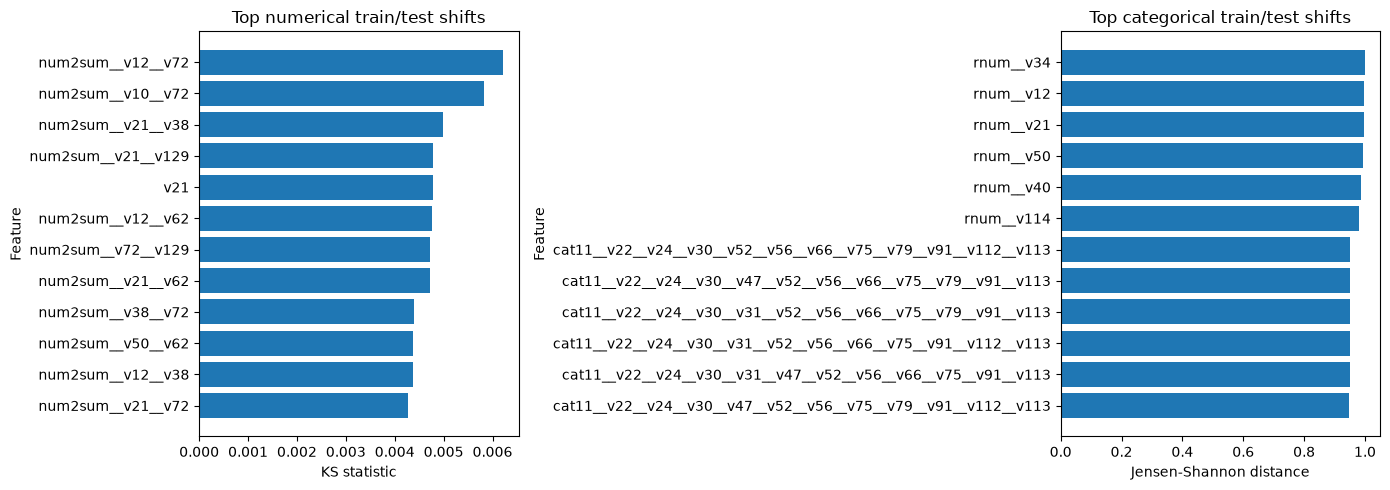

In [12]:
numerical_shift_rows = []
for feature in numerical_features:
    train_values = X_train[feature].dropna()
    test_values = X_test[feature].dropna()
    numerical_shift_rows.append({
        "feature": feature,
        "feature_group": manifest["feature_origin"][feature],
        "semantic_type": "numerical",
        "shift_metric": "ks_statistic",
        "shift_value": ks_2samp(train_values, test_values).statistic,
        "train_mean": train_values.mean(),
        "test_mean": test_values.mean(),
        "train_missing_rate": X_train[feature].isna().mean(),
        "test_missing_rate": X_test[feature].isna().mean(),
        "train_unique": np.nan,
        "test_unique": np.nan,
        "test_only_ratio": np.nan,
    })

categorical_shift_rows = []
for row in feature_cardinality.itertuples(index=False):
    train_probability = X_train[row.feature].value_counts(normalize=True, dropna=False, sort=False)
    test_probability = X_test[row.feature].value_counts(normalize=True, dropna=False, sort=False)
    aligned = pd.concat([train_probability, test_probability], axis=1).fillna(0.0)
    categorical_shift_rows.append({
        "feature": row.feature,
        "feature_group": row.feature_group,
        "semantic_type": "categorical",
        "shift_metric": "js_distance",
        "shift_value": jensenshannon(aligned.iloc[:, 0], aligned.iloc[:, 1], base=2),
        "train_mean": np.nan,
        "test_mean": np.nan,
        "train_missing_rate": 0.0,
        "test_missing_rate": 0.0,
        "train_unique": row.train_unique,
        "test_unique": row.test_unique,
        "test_only_ratio": row.test_only_ratio,
    })

numerical_shift = pd.DataFrame(numerical_shift_rows).sort_values("shift_value", ascending=False)
categorical_shift = pd.DataFrame(categorical_shift_rows).sort_values("shift_value", ascending=False)
train_test_shift = pd.concat([numerical_shift, categorical_shift], ignore_index=True)
train_test_shift.to_csv(METRICS_DIR / "train_test_shift.csv", index=False)
display(numerical_shift.head(15))
display(categorical_shift.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_numerical_shift = numerical_shift.head(12).sort_values("shift_value")
top_categorical_shift = categorical_shift.head(12).sort_values("shift_value")
axes[0].barh(top_numerical_shift["feature"], top_numerical_shift["shift_value"])
axes[0].set(title="Top numerical train/test shifts", xlabel="KS statistic", ylabel="Feature")
axes[1].barh(top_categorical_shift["feature"], top_categorical_shift["shift_value"])
axes[1].set(title="Top categorical train/test shifts", xlabel="Jensen-Shannon distance", ylabel="Feature")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_analysis_train_test_shift.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
numerical_description = pd.DataFrame({
    "min": X_train[numerical_features].min(),
    "max": X_train[numerical_features].max(),
    "mean": X_train[numerical_features].mean(),
    "median": X_train[numerical_features].median(),
    "std": X_train[numerical_features].std(),
    "skewness": X_train[numerical_features].skew(),
    "missing_rate": X_train[numerical_features].isna().mean(),
}).reset_index(names="feature")

numerical_description["feature_group"] = numerical_description["feature"].map(manifest["feature_origin"])
numerical_description["range"] = numerical_description["max"] - numerical_description["min"]

display(numerical_description.sort_values("skewness", key=lambda values: values.abs(), ascending=False).head(15))
display(numerical_description.sort_values("range", ascending=False).head(15))

,feature,min,max,mean,median,std,skewness,missing_rate,feature_group,range
5,v38,0.000000,12.000000,0.090928,0.000000,0.583478,9.838121,0.000000,original_numerical,12.000000
60,num2sum__v38__v72,0.000000,24.000000,1.522695,1.000000,1.328528,6.123877,0.000000,numerical_pair_sums,24.000000
62,num2sum__v38__v129,0.000000,12.000000,0.401072,0.000000,0.916356,3.895712,0.000000,numerical_pair_sums,12.000000
9,v72,0.000000,12.000000,1.431767,1.000000,0.922267,3.104242,0.000000,original_numerical,12.000000
59,num2sum__v38__v62,0.000000,12.000000,1.121622,1.000000,0.836435,2.889096,0.000000,numerical_pair_sums,12.000000
11,v129,0.000000,11.000000,0.310144,0.000000,0.693262,2.864833,0.000000,original_numerical,11.000000
76,num2sum__v72__v129,0.000000,22.000000,1.741911,1.000000,1.400983,2.762411,0.000000,numerical_pair_sums,22.000000
26,num2sum__v12__v38,0.000001,20.230938,6.972301,6.637398,1.088145,2.604378,0.000752,numerical_pair_sums,20.230937
58,num2sum__v38__v50,-0.000001,19.999999,1.595262,1.250092,1.326823,2.162538,0.000752,numerical_pair_sums,20.000000
12,num2sum__v10__v12,1.575493,37.244467,8.764291,7.967949,2.268870,2.006027,0.000752,numerical_pair_sums,35.668974


,feature,min,max,mean,median,std,skewness,missing_rate,feature_group,range
15,num2sum__v10__v34,0.889311,38.533917,8.289104,8.112224,2.722594,0.340993,0.000971,numerical_pair_sums,37.644606
70,num2sum__v50__v114,1.222215,38.789828,15.076453,15.413639,2.985312,-0.357714,0.000988,numerical_pair_sums,37.567613
55,num2sum__v34__v114,-0.000001,37.315973,19.978436,20.551306,4.536766,-0.357680,0.000988,numerical_pair_sums,37.315974
12,num2sum__v10__v12,1.575493,37.244467,8.764291,7.967949,2.268870,2.006027,0.000752,numerical_pair_sums,35.668974
25,num2sum__v12__v34,4.039977,38.710551,13.287391,13.264293,2.401927,0.145219,0.000988,numerical_pair_sums,34.670574
21,num2sum__v10__v114,1.291029,35.849889,15.455047,15.839607,2.833277,-0.579018,0.000988,numerical_pair_sums,34.558859
63,num2sum__v40__v50,0.460728,31.396426,11.970144,11.897637,3.460691,-0.085199,0.000988,numerical_pair_sums,30.935697
37,num2sum__v14__v50,0.234126,30.338148,13.606970,13.235390,2.091084,0.841353,0.000752,numerical_pair_sums,30.104022
31,num2sum__v12__v114,6.548070,36.026523,20.453429,20.889616,2.622324,-0.665572,0.000988,numerical_pair_sums,29.478453
35,num2sum__v14__v38,-0.000001,27.280898,12.185210,11.977198,1.608835,0.709317,0.000035,numerical_pair_sums,27.280899


,feature,feature_group,semantic_type,association_metric,association_score
71,num2sum__v50__v129,numerical_pair_sums,numerical,absolute_point_biserial,0.253668
7,v50,original_numerical,numerical,absolute_point_biserial,0.241683
58,num2sum__v38__v50,numerical_pair_sums,numerical,absolute_point_biserial,0.240059
69,num2sum__v50__v72,numerical_pair_sums,numerical,absolute_point_biserial,0.231199
37,num2sum__v14__v50,numerical_pair_sums,numerical,absolute_point_biserial,0.227447
18,num2sum__v10__v50,numerical_pair_sums,numerical,absolute_point_biserial,0.225639
28,num2sum__v12__v50,numerical_pair_sums,numerical,absolute_point_biserial,0.221202
45,num2sum__v21__v50,numerical_pair_sums,numerical,absolute_point_biserial,0.212443
52,num2sum__v34__v50,numerical_pair_sums,numerical,absolute_point_biserial,0.194542
68,num2sum__v50__v62,numerical_pair_sums,numerical,absolute_point_biserial,0.178111


,feature,feature_group,semantic_type,association_metric,association_score
161,rnum__v34,rounded_numeric_categories,categorical,mutual_information,0.549373
158,rnum__v12,rounded_numeric_categories,categorical,mutual_information,0.549077
160,rnum__v21,rounded_numeric_categories,categorical,mutual_information,0.547081
164,rnum__v50,rounded_numeric_categories,categorical,mutual_information,0.546184
213,cat11__v22__v24__v30__v52__v56__v66__v75__v79_...,high_order_v22_interactions,categorical,mutual_information,0.545016
198,cat11__v22__v24__v30__v31__v52__v56__v66__v75_...,high_order_v22_interactions,categorical,mutual_information,0.544944
206,cat11__v22__v24__v30__v47__v52__v56__v66__v75_...,high_order_v22_interactions,categorical,mutual_information,0.544944
200,cat11__v22__v24__v30__v31__v52__v56__v66__v75_...,high_order_v22_interactions,categorical,mutual_information,0.544890
173,cat11__v22__v24__v30__v31__v47__v52__v56__v66_...,high_order_v22_interactions,categorical,mutual_information,0.544818
210,cat11__v22__v24__v30__v47__v52__v56__v75__v79_...,high_order_v22_interactions,categorical,mutual_information,0.544769


,feature_group,semantic_type,association_metric,feature_count,median_association,mean_association,max_association,strongest_feature
0,numerical_pair_sums,numerical,absolute_point_biserial,66,0.110134,0.109588,0.253668,num2sum__v50__v129
1,original_numerical,numerical,absolute_point_biserial,12,0.084747,0.101590,0.241683,v50
2,rounded_numeric_categories,categorical,mutual_information,12,0.413574,0.322405,0.549373,rnum__v34
3,high_order_v22_interactions,categorical,mutual_information,66,0.542677,0.541319,0.545016,cat11__v22__v24__v30__v52__v56__v66__v75__v79_...
4,categorical_3way_v22,categorical,mutual_information,66,0.307645,0.306472,0.487565,cat3__v22__v52__v56
5,categorical_2way,categorical,mutual_information,78,0.020450,0.047967,0.349371,cat2__v22__v56
6,categorical_1way,categorical,mutual_information,13,0.011619,0.016825,0.103312,cat1__v22


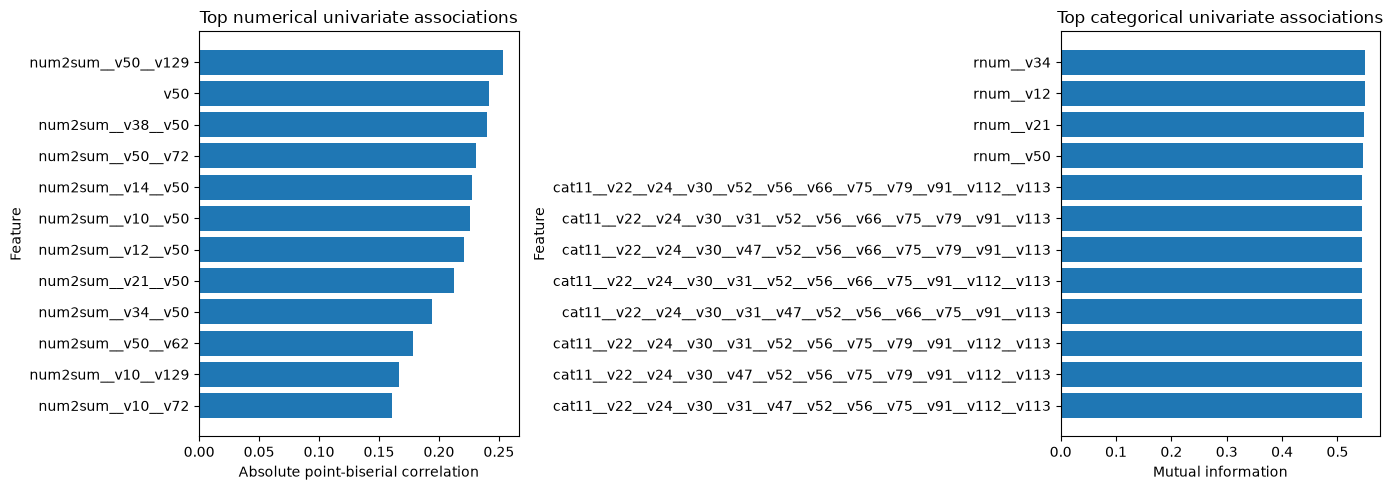

In [14]:
numerical_association_rows = []
for feature in numerical_features:
    valid = X_train[feature].notna()
    statistic = pointbiserialr(y_train.loc[valid], X_train.loc[valid, feature]).statistic
    numerical_association_rows.append({
        "feature": feature,
        "feature_group": manifest["feature_origin"][feature],
        "semantic_type": "numerical",
        "association_metric": "absolute_point_biserial",
        "association_score": abs(statistic) if np.isfinite(statistic) else 0.0,
    })

categorical_association_rows = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="The number of unique classes is greater than 50%")
    for feature in categorical_features:
        categorical_association_rows.append({
            "feature": feature,
            "feature_group": manifest["feature_origin"][feature],
            "semantic_type": "categorical",
            "association_metric": "mutual_information",
            "association_score": mutual_info_score(y_train, X_train[feature]),
        })

numerical_association = pd.DataFrame(numerical_association_rows).sort_values("association_score", ascending=False)
categorical_association = pd.DataFrame(categorical_association_rows).sort_values("association_score", ascending=False)
target_association = pd.concat([numerical_association, categorical_association], ignore_index=True)
target_association.to_csv(METRICS_DIR / "target_association.csv", index=False)

family_target_association = target_association.groupby(["feature_group", "semantic_type", "association_metric"], sort=False).agg(
    feature_count=("feature", "size"),
    median_association=("association_score", "median"),
    mean_association=("association_score", "mean"),
    max_association=("association_score", "max"),
).reset_index()
strongest_by_family = target_association.sort_values("association_score", ascending=False).drop_duplicates("feature_group")[["feature_group", "feature"]].rename(columns={"feature": "strongest_feature"})
family_target_association = family_target_association.merge(strongest_by_family, on="feature_group")
display(numerical_association.head(15))
display(categorical_association.head(15))
display(family_target_association)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_numerical_association = numerical_association.head(12).sort_values("association_score")
top_categorical_association = categorical_association.head(12).sort_values("association_score")
axes[0].barh(top_numerical_association["feature"], top_numerical_association["association_score"])
axes[0].set(title="Top numerical univariate associations", xlabel="Absolute point-biserial correlation", ylabel="Feature")
axes[1].barh(top_categorical_association["feature"], top_categorical_association["association_score"])
axes[1].set(title="Top categorical univariate associations", xlabel="Mutual information", ylabel="Feature")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_analysis_target_association.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
numerical_shift_threshold = numerical_shift["shift_value"].quantile(0.9)
categorical_shift_threshold = categorical_shift["shift_value"].quantile(0.9)
train_test_shift["high_shift"] = np.where(
    train_test_shift["semantic_type"].eq("numerical"),
    train_test_shift["shift_value"] >= numerical_shift_threshold,
    train_test_shift["shift_value"] >= categorical_shift_threshold,
)

feature_family_health = feature_info.groupby(["feature_group", "semantic_type"], sort=False).size().rename("feature_count").reset_index()
feature_family_health = feature_family_health.merge(missingness_by_group[["feature_group", "features_with_missing"]], on="feature_group", how="left")

median_cardinality = feature_cardinality.groupby("feature_group")["train_unique"].median().rename("median_cardinality")
near_constant_count = near_constant_features.groupby("feature_group").size().rename("near_constant_count")
high_shift_count = train_test_shift.loc[train_test_shift["high_shift"]].groupby("feature_group").size().rename("high_shift_count")
strongest_features = target_association.sort_values("association_score", ascending=False).drop_duplicates("feature_group")[["feature_group", "feature", "association_metric", "association_score"]].rename(columns={"feature": "strongest_univariate_feature"})

feature_family_health = feature_family_health.merge(median_cardinality, on="feature_group", how="left").merge(near_constant_count, on="feature_group", how="left").merge(high_shift_count, on="feature_group", how="left").merge(strongest_features, on="feature_group", how="left")
feature_family_health[["near_constant_count", "high_shift_count"]] = feature_family_health[["near_constant_count", "high_shift_count"]].fillna(0).astype(int)
feature_family_health.to_csv(METRICS_DIR / "feature_family_health.csv", index=False)

display(feature_family_health)

,feature_group,semantic_type,feature_count,features_with_missing,median_cardinality,near_constant_count,high_shift_count,strongest_univariate_feature,association_metric,association_score
0,original_numerical,numerical,12,8,NaN,0,1,v50,absolute_point_biserial,0.241683
1,numerical_pair_sums,numerical,66,60,NaN,0,7,num2sum__v50__v129,absolute_point_biserial,0.253668
2,categorical_1way,categorical,13,0,10.000000,0,0,cat1__v22,mutual_information,0.103312
3,categorical_2way,categorical,78,0,114.000000,0,0,cat2__v22__v56,mutual_information,0.349371
4,categorical_3way_v22,categorical,66,0,"54,210.000000",0,0,cat3__v22__v52__v56,mutual_information,0.487565
5,high_order_v22_interactions,categorical,66,0,"107,831.500000",0,18,cat11__v22__v24__v30__v52__v56__v66__v75__v79_...,mutual_information,0.545016
6,rounded_numeric_categories,categorical,12,0,"85,871.500000",0,6,rnum__v34,mutual_information,0.549373


In [16]:
def family_value(table: pd.DataFrame, group: str, column: str) -> float:
    return float(table.loc[table["feature_group"].eq(group), column].iloc[0])

cat11_cardinality = family_value(cardinality_by_group, "high_order_v22_interactions", "median_train_cardinality")
cat11_shift = categorical_shift.loc[categorical_shift["feature_group"].eq("high_order_v22_interactions"), "shift_value"].median()
rounded_cardinality = family_value(cardinality_by_group, "rounded_numeric_categories", "median_train_cardinality")
rounded_shift = categorical_shift.loc[categorical_shift["feature_group"].eq("rounded_numeric_categories"), "shift_value"].median()
cat3_shift = categorical_shift.loc[categorical_shift["feature_group"].eq("categorical_3way_v22"), "shift_value"].median()
pair_sum_correlations = ((numerical_correlations["group_a"].eq("numerical_pair_sums")) | (numerical_correlations["group_b"].eq("numerical_pair_sums"))).sum()

ablation_candidates = pd.DataFrame([
    {"ablation_name": "expert_full", "removed_feature_group": "none", "number_of_removed_features": 0, "reason_to_test": "Reference feature set for all later comparisons."},
    {"ablation_name": "expert_without_cat11_v22", "removed_feature_group": "high_order_v22_interactions", "number_of_removed_features": manifest["generated_feature_counts"]["high_order_v22_interactions"], "reason_to_test": f"Median train cardinality is {cat11_cardinality:,.0f}; median JS distance is {cat11_shift:.4f}."},
    {"ablation_name": "expert_without_num_pair_sums", "removed_feature_group": "numerical_pair_sums", "number_of_removed_features": manifest["generated_feature_counts"]["numerical_pair_sums"], "reason_to_test": f"Numerical pair sums participate in {pair_sum_correlations} pairs with absolute correlation at least 0.98."},
    {"ablation_name": "expert_without_rounded_numeric", "removed_feature_group": "rounded_numeric_categories", "number_of_removed_features": manifest["generated_feature_counts"]["rounded_numeric_categories"], "reason_to_test": f"Median train cardinality is {rounded_cardinality:,.0f}; median JS distance is {rounded_shift:.4f}."},
    {"ablation_name": "expert_without_cat3_v22", "removed_feature_group": "categorical_3way_v22", "number_of_removed_features": manifest["generated_feature_counts"]["categorical_3way_v22"], "reason_to_test": f"Three-way interactions have median JS distance {cat3_shift:.4f} and high cardinality."},
    {"ablation_name": "expert_base_only", "removed_feature_group": "all engineered groups", "number_of_removed_features": X_train.shape[1] - manifest["generated_feature_counts"]["original_numerical"] - manifest["generated_feature_counts"]["categorical_1way"], "reason_to_test": "Control set retaining only original numerical and encoded one-way categorical features."},
])

ablation_candidates.to_csv(METRICS_DIR / "ablation_candidates.csv", index=False)
display(ablation_candidates)

,ablation_name,removed_feature_group,number_of_removed_features,reason_to_test
0,expert_full,none,0,Reference feature set for all later comparisons.
1,expert_without_cat11_v22,high_order_v22_interactions,66,"Median train cardinality is 107,832; median JS..."
2,expert_without_num_pair_sums,numerical_pair_sums,66,Numerical pair sums participate in 7 pairs wit...
3,expert_without_rounded_numeric,rounded_numeric_categories,12,"Median train cardinality is 85,872; median JS ..."
4,expert_without_cat3_v22,categorical_3way_v22,66,Three-way interactions have median JS distance...
5,expert_base_only,all engineered groups,288,Control set retaining only original numerical ...


In [18]:
missing_groups = set(feature_missingness.loc[feature_missingness["train_missing_count"] > 0, "feature_group"])
supported_missing_groups = {"original_numerical", "numerical_pair_sums"}
readiness_checks = {
    "train_test_schema_identical": X_train.columns.tolist() == X_test.columns.tolist(),
    "feature_order_identical": X_train.columns.equals(X_test.columns),
    "target_alignment_valid": len(X_train) == len(y_train),
    "target_excluded": metadata["target_name"] not in X_train,
    "ids_excluded": metadata["id_name"] not in X_train,
    "numerical_features_valid": set(numerical_features).issubset(X_train.columns),
    "categorical_features_valid": set(categorical_features).issubset(X_train.columns),
    "categorical_indices_valid": [X_train.columns[index] for index in categorical_indices] == categorical_features,
    "no_unexpected_object_dtypes": X_train.select_dtypes(include=["object", "string"]).shape[1] == 0,
    "no_duplicate_feature_names": X_train.columns.is_unique,
    "missing_only_in_supported_numerical_groups": missing_groups.issubset(supported_missing_groups) and X_train[categorical_features].isna().sum().sum() == 0,
    "feature_families_reconstructable": feature_info["feature_group"].notna().all(),
    "processed_artifacts_loaded": all(len(frame) > 0 for frame in [X_train, X_test, y_train_frame, train_ids, test_ids]),
}
readiness = pd.Series(readiness_checks, name="passed").rename_axis("check").reset_index()
display(readiness)
blocking_issues = readiness.loc[~readiness["passed"], "check"].tolist()
if blocking_issues:
    print("Blocking issues:", blocking_issues)

expected_metric_files = [
    "feature_group_summary.csv", "feature_semantics_summary.csv", "feature_missingness.csv",
    "feature_cardinality.csv", "feature_near_constant.csv", "feature_duplicates.csv",
    "numerical_correlations.csv", "train_test_shift.csv", "target_association.csv",
    "feature_family_health.csv", "ablation_candidates.csv",
]
expected_figure_files = [
    "feature_analysis_feature_groups.png", "feature_analysis_missingness.png",
    "feature_analysis_cardinality.png", "feature_analysis_train_test_shift.png",
    "feature_analysis_target_association.png",
]

,check,passed
0,train_test_schema_identical,True
1,feature_order_identical,True
2,target_alignment_valid,True
3,target_excluded,True
4,ids_excluded,True
5,numerical_features_valid,True
6,categorical_features_valid,True
7,categorical_indices_valid,True
8,no_unexpected_object_dtypes,True
9,no_duplicate_feature_names,True
